**EXPERIMENT 1: LINEAR REGRESSION**

---



Q1. Import dataset and understand its structure

In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/Yashappin/Machine-Learning/master/TvMarketing.csv"
df = pd.read_csv(url)

print(df.head())
print("Shape:", df.shape)
print(df.info())
print(df.describe())

      TV  Sales
0  230.1   22.1
1   44.5   10.4
2   17.2    9.3
3  151.5   18.5
4  180.8   12.9
Shape: (200, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   TV      200 non-null    float64
 1   Sales   200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB
None
               TV       Sales
count  200.000000  200.000000
mean   147.042500   14.022500
std     85.854236    5.217457
min      0.700000    1.600000
25%     74.375000   10.375000
50%    149.750000   12.900000
75%    218.825000   17.400000
max    296.400000   27.000000


Q2. Visualize data using plot

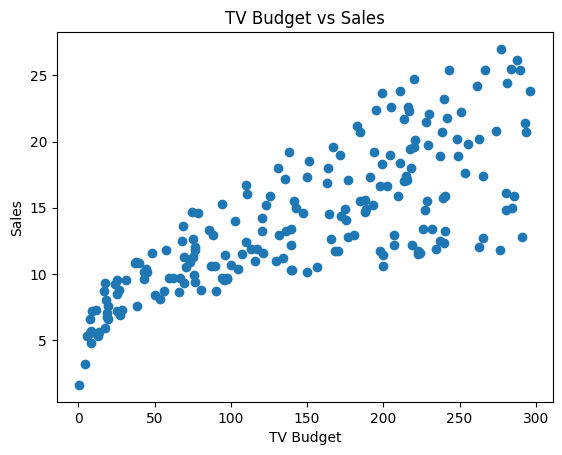

In [2]:
import matplotlib.pyplot as plt

plt.scatter(df['TV'], df['Sales'])
plt.xlabel("TV Budget")
plt.ylabel("Sales")
plt.title("TV Budget vs Sales")
plt.show()

Q3. Split data into training and testing (80:20)

In [3]:
from sklearn.model_selection import train_test_split

X = df[['TV']]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (160, 1)
Testing Shape: (40, 1)


Q4. Train Linear Regression Model & find equation

Intercept: 7.119638430592953
Slope: 0.046529733705443346


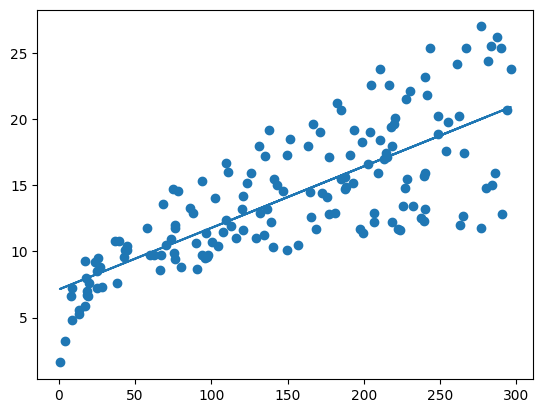

In [4]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])

# Plot best fit line
plt.scatter(X_train, y_train)
plt.plot(X_train, model.predict(X_train))
plt.show()

Q5. Display actual vs predicted values

In [5]:
y_pred = model.predict(X_test)

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print(comparison.head())

   Actual  Predicted
0    16.9  14.717944
1    22.4  16.211548
2    21.4  20.748197
3     7.3   7.664036
4    24.7  17.370139


Q6. Calculate RMSE and R² score

In [6]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2 Score:", r2)

RMSE: 3.194472431998898
R2 Score: 0.6766954295627076


**EXPERIMENT 2: MULTIPLE LINEAR REGRESSION**

Q1. Load dataset and understand structure

In [7]:
df = pd.read_csv("DATA.csv")

print(df.head())
print(df.shape)
print(df.info())
print(df.describe())

       Car    Model  Volume  Weight  CO2
0   Toyota  Corolla    1300    1200   99
1    Honda    Civic    1500    1300  104
2  Hyundai      i20    1200    1100   95
3     Ford    Focus    1600    1400  109
4      BMW     320i    2000    1500  117
(15, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Car     15 non-null     object
 1   Model   15 non-null     object
 2   Volume  15 non-null     int64 
 3   Weight  15 non-null     int64 
 4   CO2     15 non-null     int64 
dtypes: int64(3), object(2)
memory usage: 732.0+ bytes
None
            Volume       Weight         CO2
count    15.000000    15.000000   15.000000
mean   1546.666667  1326.666667  105.733333
std     306.749471   198.985522    9.137573
min    1000.000000   900.000000   90.000000
25%    1350.000000  1225.000000  100.000000
50%    1500.000000  1350.000000  105.000000
75%    1700.000000  1475

Q2. Correlation heatmap

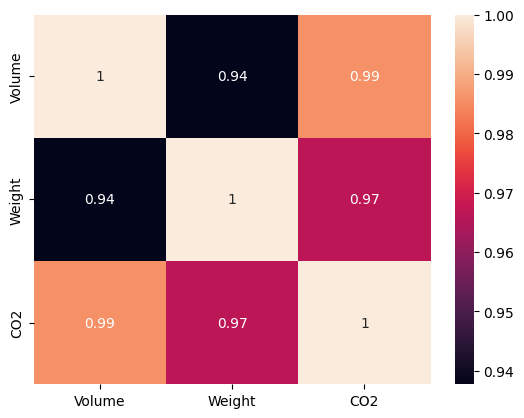

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

data = df[['Volume', 'Weight', 'CO2']]
corr = data.corr()

sns.heatmap(corr, annot=True)
plt.show()

Q3. Detect outliers using boxplot

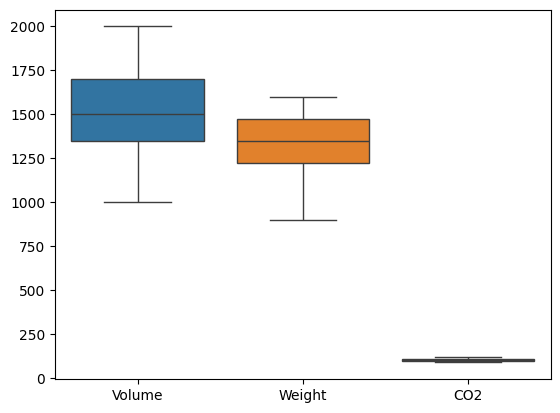

In [9]:
sns.boxplot(data=data)
plt.show()

Q4. Scatter plot (relation with CO2)

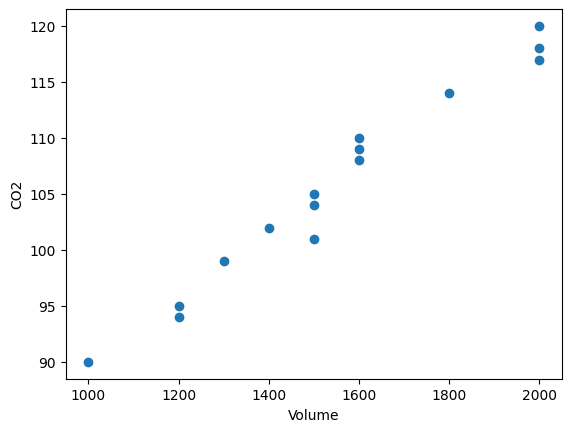

In [10]:
plt.scatter(df['Volume'], df['CO2'])
plt.xlabel("Volume")
plt.ylabel("CO2")
plt.show()

Q5. Train Multiple Linear Regression

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df[['Volume', 'Weight']]
y = df['CO2']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

Q6. Find coefficients & visualize prediction

Intercept: 55.34330889092577
Coefficients: [0.02091705 0.01358295]


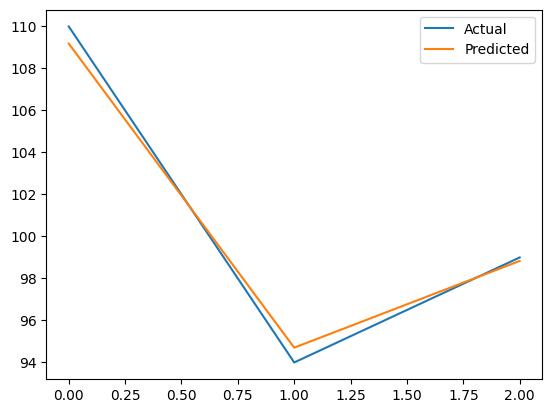

In [12]:
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

y_pred = model.predict(X_test)

plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.show()

Q7. Calculate MAE, MSE, RMSE

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)

MAE: 0.5619462267033318
MSE: 0.39655670453727954
RMSE: 0.6297274843432511


**EXPERIMENT 3: LOGISTIC REGRESSION**

Q1. Load dataset and display info

In [14]:
df = pd.read_csv("advertising.csv")

print(df.head())
print(df.info())
print(df.describe())

   Daily Time Spent on Site  Age  Area Income  Daily Internet Usage  Male  \
0                        68   25        50000                   200     1   
1                        72   30        60000                   220     0   
2                        65   28        55000                   210     1   
3                        80   35        70000                   250     0   
4                        55   22        40000                   180     1   

   Clicked on Ad  
0              0  
1              1  
2              0  
3              1  
4              0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Daily Time Spent on Site  50 non-null     int64
 1   Age                       50 non-null     int64
 2   Area Income               50 non-null     int64
 3   Daily Internet Usage      50 non-null     int64
 4 

Q2. Data preprocessing (EDA)

In [15]:
# Missing values
print(df.isnull().sum())

# Drop unnecessary columns
df = df.drop(['Ad Topic Line', 'City', 'Country', 'Timestamp'], axis=1, errors='ignore')

Daily Time Spent on Site    0
Age                         0
Area Income                 0
Daily Internet Usage        0
Male                        0
Clicked on Ad               0
dtype: int64


Q3. Correlation heatmap

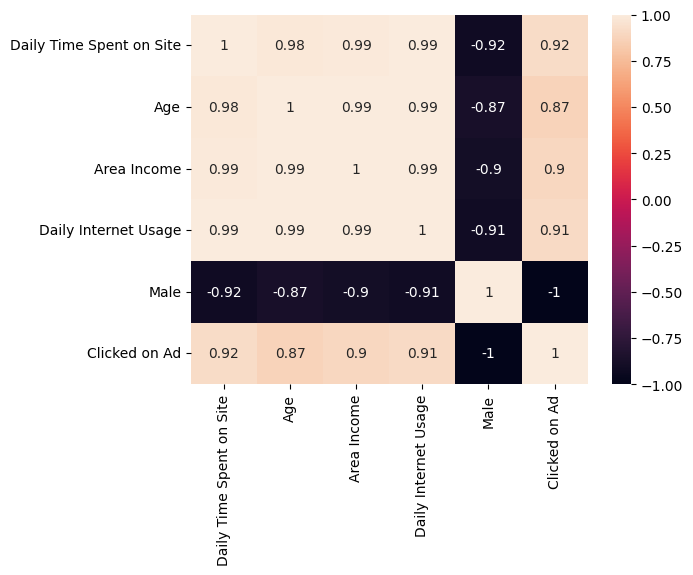

In [16]:
import seaborn as sns

sns.heatmap(df.corr(), annot=True)
plt.show()

Q4. Train Logistic Regression

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

X = df.drop('Clicked on Ad', axis=1)
y = df['Clicked on Ad']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

Intercept: [0.2777031]
Coefficients: [[ 0.79031227  0.6070383   0.69066186  0.71710451 -1.43763576]]


Q5. K-Fold Cross Validation

In [18]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X_scaled, y, cv=5)

print("Scores:", scores)
print("Average:", scores.mean())

Scores: [1. 1. 1. 1. 1.]
Average: 1.0


Q6. Classification Report

In [19]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         6

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



Q7. Confusion Matrix

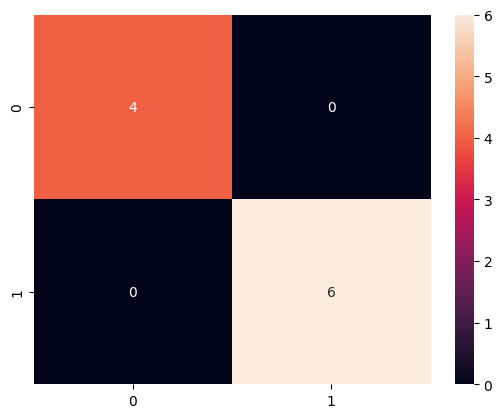

In [20]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True)
plt.show()

Q8. Actual vs Predicted Plot